[![Text: CC BY-SA 4.0](https://img.shields.io/badge/text-CC%20BY--SA%204.0-lightgrey.svg)](https://creativecommons.org/licenses/by-sa/4.0/)
[![Code: MIT](https://img.shields.io/badge/code-MIT-yellow.svg)](https://opensource.org/license/mit)

This notebook is part of course materials for CS 545: Machine Learning at
Colorado State University. These notebooks are based on the PyTorch version of
[Dive into Deep Learning](https://d2l.ai) by Aston Zhang, Zachary C. Lipton,
Mu Li and Alexander J. Smola, used under
[CC BY-SA 4.0](https://creativecommons.org/licenses/by-sa/4.0/) and heavily
modified by [Asa Ben-Hur](https://www.cs.colostate.edu/~asa/) with
[Claude](https://claude.com) AI. The text is released under
[CC BY-SA 4.0](https://creativecommons.org/licenses/by-sa/4.0/); the code is
released under the [MIT license](https://opensource.org/license/mit).

# Concise Implementation of Softmax Regression

In this notebook we will use more of the PyTorch functionality to implement softmax regression.

In [1]:
import torch
from torch import nn

import numpy as np
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

In [2]:
# if you have a GPU we should enable it
# mps is the pytorch device that supports GPU computations on MacOS

device = (
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Using {device} device")

Using mps device


## Defining the Model

This implementation uses the PyTorch `Sequential` construct to create a network as a sequence of operations.
As we did previously we construct our fully connected layer  using the built-in layer. 
The built-in `__call__` method then invokes `forward`  whenever we need to apply the network to some input.
We use a `Flatten` layer (instead of `torch.flatten`) to convert the four dimensional tensor `X` to two dimensions.

In [3]:
class SoftmaxRegression(nn.Module):
    """The softmax regression model."""
    def __init__(self, num_outputs):
        super().__init__()
        self.net = nn.Sequential(nn.Flatten(),
                                 nn.LazyLinear(num_outputs))
    def forward(self, X):
        return self.net(X)

Let's see what a `Flatten` layer does to an image:

In [4]:
input = torch.randn(32, 1, 5, 5)

# by default nn.Flatten starts flattening from dimension 1, maintaining the batch dimension
# its signature is Flatten(start_dim=1, end_dim=-1)
m = nn.Flatten()
output = m(input)
input.size(), output.size()

(torch.Size([32, 1, 5, 5]), torch.Size([32, 25]))

## Softmax Revisited

In the previous notebook we calculated our model's output
and applied the cross-entropy loss. While this is perfectly
reasonable mathematically, it is risky computationally, because of
numerical underflow and overflow in the exponentiation.

Recall that the softmax function computes probabilities via
$\hat y_j = \frac{\exp(o_j)}{\sum_k \exp(o_k)}$.
If some of the $o_k$ are very large, i.e., very positive,
then $\exp(o_k)$ might be larger than the largest number
we can have for certain data types. This is called *overflow*. Likewise,
if every argument is a very large negative number, we will get *underflow*.
For instance, single precision floating point numbers approximately
cover the range of $10^{-38}$ to $10^{38}$. As such, if the largest term in $\mathbf{o}$
lies outside the interval $[-90, 90]$, the result will not be stable.
A way around this problem is to subtract $\bar{o} \stackrel{\textrm{def}}{=} \max_k o_k$ from
all entries:

$$
\hat y_j = \frac{\exp o_j}{\sum_k \exp o_k} =
\frac{\exp(o_j - \bar{o})}{\sum_k \exp (o_k - \bar{o})}.
$$

By construction we know that $o_j - \bar{o} \leq 0$ for all $j$. 
Moreover, the
numerator never exceeds $1$, thus preventing numerical overflow. Numerical underflow only
occurs when $\exp(o_j - \bar{o})$ numerically evaluates as $0$. Nonetheless, a few steps down
the road we might find ourselves in trouble when we want to compute $\log \hat{y}_j$ as $\log 0$.
In particular, in backpropagation,
we might find ourselves faced with a screenful
of the dreaded `NaN` (Not a Number) results.

Fortunately, we are saved by the fact that
even though we are computing exponential functions,
we ultimately intend to take their log
(when calculating the cross-entropy loss).
By combining softmax and cross-entropy,
we can escape the numerical stability issues altogether. We have:

$$
\log \hat{y}_j =
\log \frac{\exp(o_j - \bar{o})}{\sum_k \exp (o_k - \bar{o})} =
o_j - \bar{o} - \log \sum_k \exp (o_k - \bar{o}).
$$

This avoids both overflow and underflow.
We will want to keep the conventional softmax function handy
in case we ever want to evaluate the output probabilities by our model.
But **instead of passing softmax probabilities into the loss function,
we just pass the logits and compute the softmax and its log
all at once inside the cross-entropy loss function**.


## Training the model

Next we train our model on Fashion-MNIST.  We use the same data loaders as in our previous notebook:


In [5]:
def load_fashion_mnist(batch_size, resize=None):
    trans = [transforms.ToTensor()]
    if resize:
        trans.insert(0, transforms.Resize(resize))
    trans = transforms.Compose(trans)
    
    train_dataset = datasets.FashionMNIST(
        root='../data',
        train=True,
        download=True,
        transform=trans
    )
    test_dataset = datasets.FashionMNIST(
        root='../data',
        train=False,
        download=True,
        transform=trans
    )
    
    return (
        DataLoader(train_dataset, batch_size=batch_size, shuffle=True),
        DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    )

In [6]:
def train_epoch(model, train_loader, loss_fn, optimizer):
    model.train()
    total_loss = 0.0   # sum of per-example losses
    total_examples = 0
    for X, y in train_loader:
        X, y = X.to(device), y.to(device)
        y_pred = model(X)
        loss = loss_fn(y_pred, y)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        # loss_fn returns the mean over the batch, so multiply back out by the
        # batch size to accumulate an exact, example-weighted average (the final
        # batch is smaller, so a plain mean of batch means would be biased).
        total_loss += loss.item() * y.numel()
        total_examples += y.numel()
    return total_loss / total_examples


def correctly_classified(y_hat, y):
    """Return the NUMBER of correct predictions in a batch (not a rate)."""
    if len(y_hat.shape) > 1:
        y_hat = y_hat.argmax(dim=1)
    return (y_hat == y).type(torch.float32).sum().item()


def evaluate(model, loss_fn, data_loader):
    model.eval()
    total_loss = 0.0
    correct = 0.0
    total = 0
    with torch.no_grad():
        for X, y in data_loader:
            X, y = X.to(device), y.to(device)
            y_pred = model(X)
            total_loss += loss_fn(y_pred, y).item() * y.numel()
            correct += correctly_classified(y_pred, y)
            total += y.numel()
    return correct / total, total_loss / total

In [7]:
train_loader, valid_loader = load_fashion_mnist(batch_size=256)
model = SoftmaxRegression(num_outputs=10)
model = model.to(device)
optimizer = torch.optim.SGD(model.parameters(), lr=0.1)
loss_fn = nn.CrossEntropyLoss()

Before training, a quick note on label dtype. Unlike the from-scratch notebook, here we
use the built-in `nn.CrossEntropyLoss`, which expects the **targets to be integer class
indices** (`torch.int64`), not one-hot vectors or floats. `FashionMNIST` already provides
labels in this form, which we can verify:

In [8]:
X_batch, y_batch = next(iter(train_loader))
y_batch.dtype   # torch.int64 — the integer class indices CrossEntropyLoss expects

torch.int64

In [9]:
epochs = 15
# overall loss / accuracy value for each epoch:
train_losses, valid_losses, valid_accs = [], [] , []

for epoch in range(epochs) :
    print("epoch", epoch + 1)
    train_loss = train_epoch(model, train_loader, loss_fn, optimizer)
    valid_acc, valid_loss = evaluate(model, loss_fn, valid_loader)
    train_losses.append(train_loss)
    valid_losses.append(valid_loss)
    valid_accs.append(valid_acc)
    print ("loss", train_loss, "accuracy: ", valid_acc)

epoch 1
loss 0.7858820243835449 accuracy:  0.7739
epoch 2
loss 0.5712044222831726 accuracy:  0.805
epoch 3
loss 0.5258932004451752 accuracy:  0.8186
epoch 4
loss 0.5019066067059835 accuracy:  0.8119
epoch 5
loss 0.4857014766375224 accuracy:  0.8002
epoch 6
loss 0.47382670203844707 accuracy:  0.8205
epoch 7
loss 0.4650921533425649 accuracy:  0.829
epoch 8
loss 0.4582715092976888 accuracy:  0.8324
epoch 9
loss 0.4522888730208079 accuracy:  0.8295
epoch 10
loss 0.4472230093797048 accuracy:  0.8323
epoch 11
loss 0.443345192527771 accuracy:  0.8349
epoch 12
loss 0.439091371122996 accuracy:  0.8344
epoch 13
loss 0.4368685181935628 accuracy:  0.8279
epoch 14
loss 0.43288886499404905 accuracy:  0.8299
epoch 15
loss 0.43056009141604107 accuracy:  0.8359


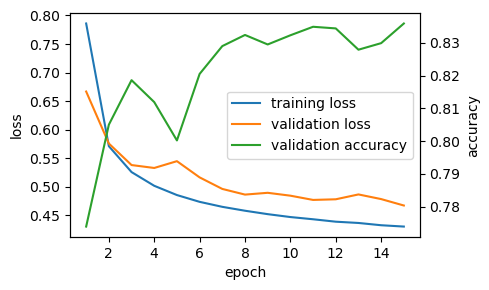

In [10]:
from matplotlib import pyplot as plt

epochs_axis = range(1, len(train_losses) + 1)
fig, ax_loss = plt.subplots(figsize=(5, 3))

# left y-axis: losses
l1 = ax_loss.plot(epochs_axis, train_losses, label='training loss')
l2 = ax_loss.plot(epochs_axis, valid_losses, label='validation loss')
ax_loss.set_xlabel('epoch')
ax_loss.set_ylabel('loss')

# right y-axis: accuracy (different scale, so give it its own axis)
ax_acc = ax_loss.twinx()
l3 = ax_acc.plot(epochs_axis, valid_accs, label='validation accuracy',
                 color='tab:green')
ax_acc.set_ylabel('accuracy')

# combine the legends from both axes into one
lines = l1 + l2 + l3
ax_loss.legend(lines, [ln.get_label() for ln in lines], loc='center right')
plt.tight_layout();

As before, this algorithm converges to a solution
that is reasonably accurate, albeit this time with fewer lines of code than before.


## Summary

High-level APIs are very convenient at hiding from their user potentially dangerous aspects, such as numerical stability. Moreover, they allow users to design models concisely with very few lines of code. This is both a blessing and a curse. The obvious benefit is that it makes things highly accessible. However, you lose the complete understanding that a fully from-scratch implementation provides.

As such, we strongly urge you to review *both* the bare bones and the elegant versions of many of the implementations that follow. While we emphasize ease of understanding, the implementations are nonetheless usually quite performant. It is our intention to allow you to build on these when you invent something new that is not available in the standard frameworks.


## Exercises

1. Increase the number of epochs for training. Why might the validation accuracy decrease after a while? How could we fix this?
1. What happens as you increase the learning rate? Compare the loss curves for several learning rates. Which one works better?
